In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Đọc dữ liệu từ file csv
merged_df = pd.read_csv("../DATA EXPLORER CONTEST/Preprocessed_Data/merged_data_(t-1).csv")

In [3]:
# Loại bỏ dòng trống
merged_df.dropna(inplace=True)

In [4]:
# Đặt cột Date làm index
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df.set_index('Date', inplace=True)

In [5]:
# --- Lấy các cột cần thiết ---
features = ['Market Cap_lag1','Closing Price_lag1',
            'Remaining Room %_lag1','Remaining Room Shares_lag1',
            'Total Sell Value_lag1',
            'Matched Sell Value_lag1','Matched Buy Value_lag1',
            'Negotiated Sell Value_lag1','Negotiated Sell Volume_lag1',
            'Negotiated Buy Value_lag1','Negotiated Buy Volume_lag1',
            'MA5','MA10']
target = 'Closing Price'

In [6]:
# --- Chuẩn hóa dữ liệu ---
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_all = scaler_x.fit_transform(merged_df[features])
y_all = scaler_y.fit_transform(merged_df[[target]])


In [7]:
# Tạo sequence dữ liệu cho mô hình LSTM
# Số ngày dùng làm độ dài sequence
sequence_length = 70

# Tạo toàn bộ sequence (X, y)
X_seq, y_seq = [], []

for i in range(sequence_length, len(X_all)):
    X_seq.append(X_all[i-sequence_length:i])
    y_seq.append(y_all[i])

X_seq, y_seq = np.array(X_seq), np.array(y_seq)


In [8]:
# Chia tập train/test theo tỷ lệ 80/20
split_index = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

# In ra shape để kiểm tra
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (128, 70, 13) (128, 1)
Test shape: (32, 70, 13) (32, 1)


In [9]:
# -------------------- Xây dựng và huấn luyện mô hình LSTM --------------------
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Huấn luyện
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# Dự đoán
y_pred = model.predict(X_test)

# Đảo ngược chuẩn hóa để ra giá trị thật
y_pred_inverse = scaler_y.inverse_transform(y_pred)
y_test_inverse = scaler_y.inverse_transform(y_test)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.2779 - val_loss: 0.1196
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0412 - val_loss: 0.0681
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0292 - val_loss: 0.0111
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0179 - val_loss: 0.0088
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0129 - val_loss: 0.0031
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0127 - val_loss: 0.0029
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0105 - val_loss: 0.0102
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0076 - val_loss: 0.0084
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0084 - val_loss: 0.0213
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0071 - val_loss: 0.0219
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0062 - val_loss: 0.0023
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0056 - val_loss: 0.0025
E

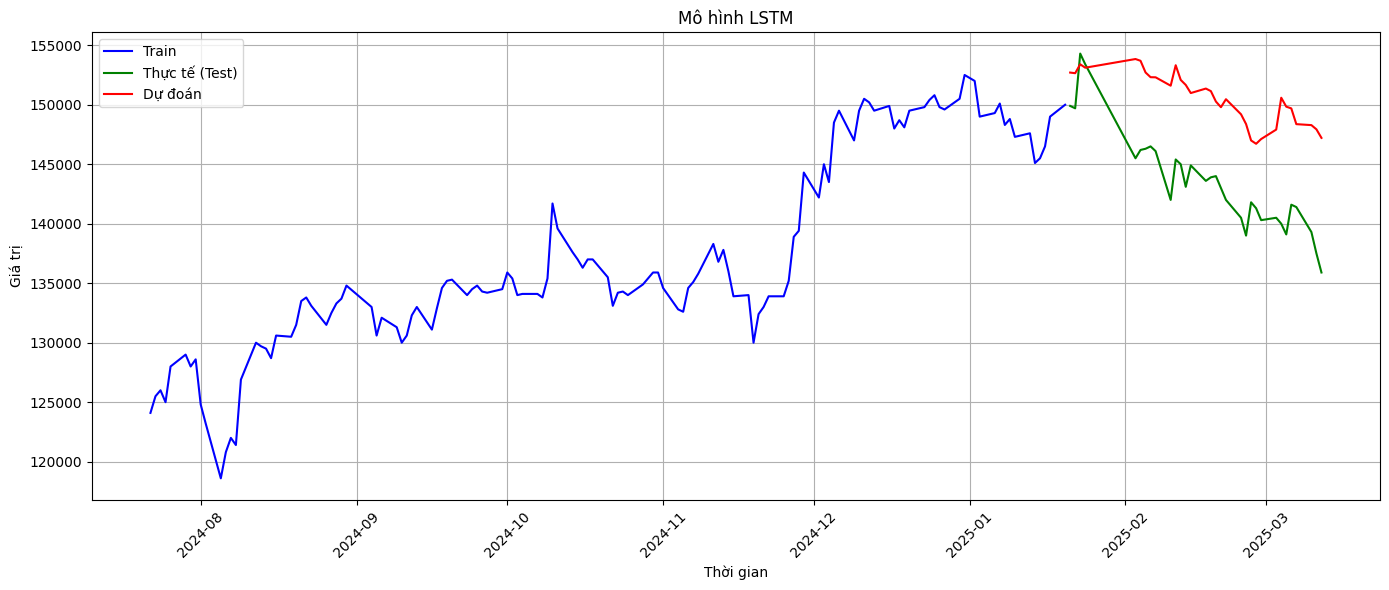

In [11]:
# Lấy thời gian tương ứng với y_train
train_start_idx = sequence_length
train_end_idx = train_start_idx + len(y_train)
train_time_index = merged_df.index[train_start_idx:train_end_idx]
y_train_inverse = scaler_y.inverse_transform(y_train)

# Lấy thời gian tương ứng với y_test
test_start_idx = sequence_length + split_index
test_end_idx = test_start_idx + len(y_test)
test_time_index = merged_df.index[test_start_idx:test_end_idx]
y_test_inverse = scaler_y.inverse_transform(y_test)
y_pred_inverse = scaler_y.inverse_transform(y_pred)

# Vẽ biểu đồ tổng hợp
plt.figure(figsize=(14, 6))
plt.plot(train_time_index, y_train_inverse, label='Train', color='blue')
plt.plot(test_time_index, y_test_inverse, label='Thực tế (Test)', color='green')
plt.plot(test_time_index, y_pred_inverse, label='Dự đoán', color='red')
plt.title('Mô hình LSTM')
plt.xlabel('Thời gian')
plt.ylabel('Giá trị')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




In [14]:
# --- In ra các giá trị thực tế sau khi inverse transform ---
print("Giá trị thực tế (y_test_inverse):")
print(y_pred_inverse.flatten())

Giá trị thực tế (y_test_inverse):
[143297.02 143710.45 144329.45 144935.12 145600.31 147059.52 147918.89
 147172.6  146775.48 146363.42 146038.92 145627.94 144672.94 144535.17
 144300.6  143896.28 143955.66 143833.05 143835.7  143877.61 143802.95
 143634.39 143287.   142873.34 143037.55 143087.5  143041.34 143076.6
 143027.61 142948.86 143288.44 143506.45 143366.81]


In [15]:
# --- Đánh giá mô hình ---
mse = mean_squared_error(y_test_inverse, y_pred_inverse)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
r2 = r2_score(y_test_inverse, y_pred_inverse)

# --- In kết quả ---
print(f"MSE  (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAE  (Mean Absolute Error): {mae:.2f}")
print(f"R²   (R-squared): {r2:.4f}")

MSE  (Mean Squared Error): 14504470.32
RMSE (Root Mean Squared Error): 3808.47
MAE  (Mean Absolute Error): 2841.12
R²   (R-squared): 0.1886
